# Tái hiện bài báo ConEm

**ConEm: A novel framework for integrating external factors with inner and outer correlations in time series forecasting**
Hoang Nguyen Nguyen, Wei Xiang, Lianhua Chi, Mike Da Gama, Sanjeevani Avashi, Michael Treloar, Lu Yu
*Knowledge-Based Systems* **329** (2025) 114312 · [doi:10.1016/j.knosys.2025.114312](https://doi.org/10.1016/j.knosys.2025.114312) · CC BY
Repo tác giả: <https://github.com/anonymous7594/conem>

---

## Notebook này làm gì

1. Kiểm kê **cái gì tái hiện được** trong 5 thực nghiệm của bài báo
2. Tải dữ liệu benchmark của chính tác giả
3. Chỉ ra **hai lỗi thật** khiến code đã công bố không chạy
4. **Kiểm chứng rò rỉ thông tin** trong thực nghiệm Weather — phần quan trọng nhất
5. Huấn luyện lại và đối chiếu số liệu
6. Thực nghiệm **khử rò rỉ** để tách đóng góp thật của kiến trúc

## Ý tưởng của ConEm (Mục 3)

ConEm là module *plug-and-play* gắn vào backbone encoder–decoder, gồm:

| Thành phần | Đầu vào | Vai trò |
|---|---|---|
| **Feature Tokenizer** | mọi loại đặc trưng | đưa numerical / categorical / static / look-back về một không gian ngữ nghĩa chung |
| **PaEm** (Past) | ngoại sinh quá khứ $x^c_{T-l:T}, x^n_{T-l:T}$ | ảnh hưởng của quá khứ lên mẫu tương lai |
| **FuEm** (Future) | ngoại sinh tương lai $x^c_{T+1:T+h}, x^n_{T+1:T+h}$ | yếu tố ngoại sinh **đã biết trước** |
| **LoEm** (Local) | static $x^s$ + look-back $x^d_{T-l:T}$ | cổng nhân điều chỉnh tỉ lệ tác động cho từng chuỗi |

$$\mathcal{C}^t_{T-l:T} = \mathrm{PaEm}(\cdot)\cdot\mathrm{LoEm}(\cdot), \qquad
\mathcal{C}^t_{T+1:T+h} = \mathrm{FuEm}(\cdot)\cdot\mathrm{LoEm}(\cdot)$$

---
## 1. Môi trường

Máy: **Apple M5, 16 GB, không CUDA**. PyTorch chạy trên **MPS**.

In [1]:
import os, sys, subprocess, json, re
from pathlib import Path

REPRO = Path.cwd() if Path.cwd().name == 'repro' else Path.cwd() / 'repro'
PY = str(REPRO.parent / '.venv' / 'bin' / 'python')
os.chdir(REPRO)
UPSTREAM = REPRO / 'upstream' / 'conem'   # 100% TÁC GIẢ, không bao giờ sửa
BUILD    = REPRO / 'build' / 'conem'      # SINH RA = upstream + ours/patches
OURS     = REPRO / 'ours'                 # 100% CỦA CHÚNG TA
print('thư mục làm việc:', REPRO)
print('python của venv  :', PY, '(tồn tại:', os.path.exists(PY), ')')

thư mục làm việc: /Users/ngkky/Data Science/repro
python của venv  : /Users/ngkky/Data Science/.venv/bin/python (tồn tại: True )


In [2]:
import torch, numpy as np, pandas as pd, matplotlib
print(f"torch  {torch.__version__}")
print(f"numpy  {np.__version__}   (phải < 2: repo dùng np.Inf đã bị NumPy 2 bỏ)")
print(f"pandas {pd.__version__}")
print(f"MPS khả dụng: {torch.backends.mps.is_available()}")

torch  2.8.0
numpy  1.26.4   (phải < 2: repo dùng np.Inf đã bị NumPy 2 bỏ)
pandas 2.3.3
MPS khả dụng: True


---
## 2. Cấu trúc: ba tầng, ranh giới dứt khoát

```
repro/
├── upstream/conem/   100% CỦA TÁC GIẢ. Không bao giờ sửa. Còn .git để kiểm chứng nguồn.
├── ours/             100% CỦA CHÚNG TA.
└── build/conem/      SINH RA = upstream + patches. Không sửa tay. Xoá được, dựng lại được.
```

Nhờ cách này, câu hỏi **"dòng code này của ai"** luôn có câu trả lời dứt khoát.

Các bản vá trong `ours/patches/` được chia hai nhóm, và đây là phân biệt quan trọng nhất
của cả bản tái hiện:

| nhóm | nghĩa |
|---|---|
| **`required/`** | Không có thì code **crash** — không chạy được gì. Không còn lựa chọn khác. |
| **`choices/`** | **Quyết định của chúng ta.** Code vẫn chạy nếu bỏ. Tức **KHÔNG** phải tái hiện trung thực. |

In [3]:
# Danh sách các bản vá, kèm nhóm
print(subprocess.run([PY, 'ours/build.py', '--list'], capture_output=True, text=True).stdout)

mã       nhóm       mô tả
--------------------------------------------------------------------------------------------
A1+A2    required   model_fed_based.py: lời gọi DataEmbedding lệch 2 tham số + không giải nén decoder
A3       required   model_without_FuEm.py: cả ba import của khối 'Custom Embedding' bị comment
A4       required   3 file baseline: os.chdir sang đường dẫn máy tác giả + import tương đối
B1       required   exp_basic.py: thêm nhánh thiết bị MPS (Apple Silicon)
B2       required   exp_main_*.py: torch.load(map_location='cuda:0') -> self.device
C1       choice     exp_main_*.py: import Model ở cấp module -> import động theo args.model_file
A6fix    choice     model_fed_based.py: RIN dùng dạng (sum+1) thay vì sum ở hệ số affine
A8       choice     exp_main_*.py: bật lại adjust_learning_rate (bị comment)
C2       choice     data_loader.py + data_factory.py: thêm stride khi cắt cửa sổ train/val
C3       choice     exp_main_*.py: bỏ đánh giá tập test sau mỗi epoch (chỉ dùng 

### 2.1 Kiểm chứng ranh giới

Ba kiểm tra dưới đây trả lời dứt khoát: code tác giả có bị sửa không, và chúng ta đã thay
đổi đúng bao nhiêu.

In [4]:
# (1) upstream/ có bị sửa không?
dirty = subprocess.run(['git', '-C', str(UPSTREAM), 'status', '--porcelain'],
                       capture_output=True, text=True).stdout.strip()
sha = subprocess.run(['git', '-C', str(UPSTREAM), 'rev-parse', '--short', 'HEAD'],
                     capture_output=True, text=True).stdout.strip()
print(f"upstream/conem commit : {sha}")
print(f"upstream/conem bị sửa : {'CÓ — cảnh báo!' if dirty else 'KHÔNG (git status sạch)'}")

# (2) quy mô code tác giả
n_files = len([f for f in UPSTREAM.rglob('*.py') if '.git' not in f.parts])
n_lines = sum(len(f.read_text(errors='ignore').split('\n'))
              for f in UPSTREAM.rglob('*.py') if '.git' not in f.parts)
print(f"\ncode tác giả          : {n_files} file .py, {n_lines:,} dòng")

# (3) code của chúng ta
ours_files = sorted(f for f in OURS.rglob('*')
                    if f.is_file() and f.suffix in ('.py', '.sh')
                    and '__pycache__' not in f.parts)
ours_lines = sum(len(f.read_text(errors='ignore').split('\n')) for f in ours_files)
print(f"code của chúng ta     : {len(ours_files)} file, {ours_lines:,} dòng")
# run.py định nghĩa những gì? Dùng AST nên không bị nhiễu bởi docstring/comment.
import ast as _ast
_tree = _ast.parse((OURS / 'runner' / 'run.py').read_text())
_classes = [n.name for n in _ast.walk(_tree) if isinstance(n, _ast.ClassDef)]
_funcs   = [n.name for n in _ast.walk(_tree) if isinstance(n, _ast.FunctionDef)]
_imports = sorted({(n.module or '') for n in _ast.walk(_tree) if isinstance(n, _ast.ImportFrom)}
                  | {a.name for n in _ast.walk(_tree) if isinstance(n, _ast.Import) for a in n.names})
print("\nours/runner/run.py — phân tích bằng AST:")
print(f"   class định nghĩa : {_classes or 'KHÔNG CÓ'}")
print(f"   hàm định nghĩa   : {_funcs}")
print(f"   import           : {_imports}")
print("\n   -> không class nào, nên không thể có nn.Module hay forward().")
print("      run.py chỉ dựng args rồi gọi lớp Exp_Main CỦA TÁC GIẢ:")
for _n in _ast.walk(_tree):
    if isinstance(_n, _ast.Call):
        _seg = _ast.get_source_segment((OURS / 'runner' / 'run.py').read_text(), _n) or ''
        if 'Exp_Main' in _seg or 'exp.train' in _seg or 'exp.test' in _seg:
            print(f"        {_seg[:70]}")

upstream/conem commit : 80f0e01
upstream/conem bị sửa : KHÔNG (git status sạch)

code tác giả          : 58 file .py, 19,430 dòng
code của chúng ta     : 23 file, 2,617 dòng

ours/runner/run.py — phân tích bằng AST:
   class định nghĩa : KHÔNG CÓ
   hàm định nghĩa   : ['build_args', 'main']
   import           : ['argparse', 'importlib', 'numpy', 'os', 'random', 'sys', 'torch']

   -> không class nào, nên không thể có nn.Module hay forward().
      run.py chỉ dựng args rồi gọi lớp Exp_Main CỦA TÁC GIẢ:
        Exp_Main(args)
        exp.train(setting)
        exp.test(setting, test=1)


---
## 3. Cái gì tái hiện được

Bài báo chạy 5 bộ dữ liệu. Hai bộ cho kết quả tốt nhất lại **không thể chia sẻ**.

In [5]:
audit = pd.DataFrame([
    ['Pharmaceutical Weekly', 'Bảng 5, 6',        'Bảo mật thương mại',        'KHÔNG'],
    ['Australian Daily POS',  'Bảng 5, 7',        'Bảo mật thương mại',        'KHÔNG'],
    ['Corporación Favorita',  'Bảng 8, 9, Hình 11','Drive favorita.zip 108 MB', 'Được'],
    ['Weather',               'Bảng 10-13, 17',   'Drive weather.zip 4.3 MB',   'ĐANG LÀM'],
    ['EPF',                   'Bảng 14-16, 18',   'Zenodo 4624805, công khai',  'Được, cần viết loader'],
], columns=['Thực nghiệm', 'Bảng trong bài', 'Dữ liệu', 'Tái hiện'])
audit

,Thực nghiệm,Bảng trong bài,Dữ liệu,Tái hiện
0,Pharmaceutical Weekly,"Bảng 5, 6",Bảo mật thương mại,KHÔNG
1,Australian Daily POS,"Bảng 5, 7",Bảo mật thương mại,KHÔNG
2,Corporación Favorita,"Bảng 8, 9, Hình 11",Drive favorita.zip 108 MB,Được
3,Weather,"Bảng 10-13, 17",Drive weather.zip 4.3 MB,ĐANG LÀM
4,EPF,"Bảng 14-16, 18","Zenodo 4624805, công khai","Được, cần viết loader"


**Chọn Weather** vì: dữ liệu chỉ 4,3 MB và là bản tiền xử lý của chính tác giả; đây là nơi
bài báo báo cáo hiệu ứng lớn nhất (`T(degC)` MSE 1,5919 → 0,0343); cùng cấu hình đó tái hiện
luôn được ablation Bảng 17.

---
## 4. Dữ liệu của tác giả

README repo trỏ tới một thư mục Google Drive. Các file và ID:

| File | Drive ID | Cỡ |
|---|---|---|
| `weather.zip` | `1TGScqj_hV3dRYNRAlwGPpcNNSECIpite` | 4,3 MB |
| `favorita.zip` | `1wITO0KWzeHRLKk8Po0oMAJDJ1UPyus-C` | 108 MB |

In [6]:
# Tải + giải nén nếu chưa có (idempotent)
WD = REPRO / 'data' / 'weather'
WD.mkdir(parents=True, exist_ok=True)
if not (WD / 'train_weather.csv').exists():
    url = ("https://drive.usercontent.google.com/download"
           "?id=1TGScqj_hV3dRYNRAlwGPpcNNSECIpite&export=download")
    subprocess.run(['curl', '-sSL', '--max-time', '180', url, '-o', 'weather.zip'], check=True)
    subprocess.run(['unzip', '-o', '-q', 'weather.zip', '-d', str(WD)], check=True)
    print('đã tải và giải nén')
else:
    print('đã có sẵn')

tr = pd.read_csv(WD / 'train_weather.csv')
te = pd.read_csv(WD / 'test_weather_df_final.csv')
print(f"train {tr.shape}  {tr['Date Time'].iloc[0]} -> {tr['Date Time'].iloc[-1]}")
print(f"test  {te.shape}  {te['Date Time'].iloc[0]} -> {te['Date Time'].iloc[-1]}")
print(f"trạm: {sorted(tr['location'].unique())}")

đã có sẵn


train (105038, 17)  2022-01-01 00:10:00 -> 2023-01-01 00:00:00
test  (26280, 17)  2023-01-01 00:10:00 -> 2023-04-02 06:00:00
trạm: ['ws_beutenberg', 'ws_saaleaue']


Khớp chính xác Mục 4.1.4: hai trạm Saaleaue / Beutenberg, 15 phép đo, chu kỳ 10 phút,
train toàn năm 2022, test 2023-01-01 → 2023-04-02.

### 4.1 Phân vai các chuỗi

Mục 4.1.4 loại 6 chuỗi khỏi danh sách target và dùng chúng làm **yếu tố ngoại sinh**:
`p`, `sh`, `Tpot`, `H2OC`, `rho` vì có giá trị khuyết; `SWDR` vì ~50% giá trị bằng 0.

In [7]:
EXT = ['p (mbar)', 'sh (g/kg)', 'Tpot (K)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'SWDR (W/m²)']
TGT = ['T (degC)', 'rh (%)', 'Tdew (degC)', 'VPmax (mbar)', 'VPact (mbar)',
       'VPdef (mbar)', 'wv (m/s)', 'wd (deg)', 'rain (mm)']
print('YẾU TỐ NGOẠI SINH (6):', EXT)
print('TARGET (9)          :', TGT)

# Giá trị sentinel -9999 còn sót trong file train của tác giả
num = tr.drop(columns=['Date Time', 'location'])
bad = (num <= -9000).sum()
print('\nSố giá trị -9999 còn lại trong train:')
print(bad[bad > 0].to_string())
print(f"-> {int((num <= -9000).any(axis=1).sum())}/{len(tr)} hàng bị nhiễm; tập test sạch.")

YẾU TỐ NGOẠI SINH (6): ['p (mbar)', 'sh (g/kg)', 'Tpot (K)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'SWDR (W/m²)']
TARGET (9)          : ['T (degC)', 'rh (%)', 'Tdew (degC)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'wv (m/s)', 'wd (deg)', 'rain (mm)']

Số giá trị -9999 còn lại trong train:
p (mbar)           261
sh (g/kg)          261
Tpot (K)           261
H2OC (mmol/mol)    261
rho (g/m**3)       261
wv (m/s)             1
SWDR (W/m²)          1
-> 263/105038 hàng bị nhiễm; tập test sạch.


> **Lưu ý.** Bài báo loại các chuỗi này khỏi *target* vì có giá trị khuyết, nhưng vẫn dùng
> chúng làm *đầu vào* ngoại sinh — với `-9999` nguyên vẹn. Ta lọc các hàng đó khi phân tích.

---
## 5. Audit repo tác giả

README ghi *"Code will be released soon"*. Lõi mô hình **có thật** và khớp bài báo:

In [8]:
# Clone CHÍNH repo của tác giả vào upstream/ (giữ .git để kiểm chứng nguồn).
URL = 'https://github.com/anonymous7594/conem'
if not UPSTREAM.exists():
    UPSTREAM.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(['git', 'clone', '--quiet', URL, str(UPSTREAM)], check=True)

print(subprocess.run(['git', '-C', str(UPSTREAM), 'remote', '-v'],
                     capture_output=True, text=True).stdout)
print('commit:', subprocess.run(['git', '-C', str(UPSTREAM), 'log', '--oneline', '-1'],
                                capture_output=True, text=True).stdout.strip())

origin	https://github.com/anonymous7594/conem (fetch)
origin	https://github.com/anonymous7594/conem (push)

commit: 80f0e01 delete old folder


### 5.0 Provenance — code này là của ai?

Mọi thứ chạy ở đây là **code của tác giả**, clone từ repo trên. Hai câu hỏi cần trả lời bằng
bằng chứng kiểm tra được, không phải bằng lời:

1. Lõi cơ chế ConEm có bị viết lại không?
2. Những gì tôi sửa là gì, chính xác bao nhiêu dòng?

In [9]:
# (1) Lõi ConEm có nguyên vẹn không? So khớp MD5 với bản gốc.
import hashlib
core = ['layers/Embed.py', 'layers/Embed_without_LoEm.py', 'layers/Embed_without_FuEm.py',
        'layers/Embed_without_PaEm.py', 'layers/Correlation.py',
        'layers/MultiWaveletCorrelation.py', 'layers/EncDecLayer.py',
        'layers/AutoCorrelation.py', 'model/model_info_based.py',
        'model/model_auto_based.py', 'model/model_fedformer.py', 'utils/metrics.py']
h = lambda p: hashlib.md5(Path(p).read_bytes()).hexdigest()
print('Lõi ConEm — so khớp byte-for-byte với bản gốc tác giả:\n')
for f in core:
    same = h(UPSTREAM / 'model' / f) == h(BUILD / 'model' / f)
    print(f"  {'GIỐNG HỆT' if same else 'đã sửa   '}  {f}")

Lõi ConEm — so khớp byte-for-byte với bản gốc tác giả:

  GIỐNG HỆT  layers/Embed.py
  GIỐNG HỆT  layers/Embed_without_LoEm.py
  GIỐNG HỆT  layers/Embed_without_FuEm.py
  GIỐNG HỆT  layers/Embed_without_PaEm.py
  GIỐNG HỆT  layers/Correlation.py
  GIỐNG HỆT  layers/MultiWaveletCorrelation.py
  GIỐNG HỆT  layers/EncDecLayer.py
  GIỐNG HỆT  layers/AutoCorrelation.py
  GIỐNG HỆT  model/model_info_based.py
  GIỐNG HỆT  model/model_auto_based.py
  đã sửa     model/model_fedformer.py
  GIỐNG HỆT  utils/metrics.py


In [10]:
# (2) Tôi đã sửa đúng những gì? Toàn bộ diff trên file mô hình.
print(subprocess.run(
    f"diff -u '{UPSTREAM}/model/model/model_fed_based.py' "
    f"'{BUILD}/model/model/model_fed_based.py' | grep -E '^[-+][^-+]'",
    shell=True, capture_output=True, text=True).stdout or '(chưa vá)')

n = subprocess.run(
    f"diff -r --exclude=__pycache__ '{UPSTREAM}/model' '{BUILD}/model' | grep -cE '^[<>]'",
    shell=True, capture_output=True, text=True).stdout.strip()
print(f"\nTổng số dòng khác bản gốc trên toàn repo: {n} (trên ~2.000 dòng code)")

-        self.enc_embedding = DataEmbedding_encoder(enc_in, d_model, embed, freq,
+        self.enc_embedding = DataEmbedding_encoder(enc_in, d_model, static_d_token, contextual_encoder_d_token, embed, freq,
-        self.dec_embedding = DataEmbedding_decoder(dec_in, d_model, embed, freq,
+        self.dec_embedding = DataEmbedding_decoder(dec_in, d_model, static_d_token, contextual_decoder_d_token, embed, freq,
-            x_enc = x_enc*torch.sum(self.affine_weight_input*x_static_enc,dim=2,keepdim=True) + torch.sum(self.affine_bias_input*x_static_enc,dim=2,keepdim=True)
+            # [vá A6fix] dạng "1 + phần học được", chính là dòng tác giả đã comment ở trên
+            x_enc = x_enc*(torch.add(torch.sum(self.affine_weight_input*x_static_enc,dim=2,keepdim=True),1)) + torch.sum(self.affine_bias_input*x_static_enc,dim=2,keepdim=True)
-        dec_out = self.dec_embedding(seasonal_init, x_mark_dec,x_temporal_dec,x_static_dec,x_past_context_init)
+        dec_out, x_future_context = s

Diff trên file mô hình **đúng 3 dòng** — chính là hai lỗi ở §5.1. Toàn bộ `layers/Embed.py`
(Feature Tokenizer, GLU, LoEm, PaEm/FuEm) và các file ablation **giống hệt từng byte**. Nghĩa
là cơ chế ConEm được đánh giá ở đây là *nguyên bản của tác giả*, không phải bản tôi viết lại.

Các thay đổi còn lại thuần về môi trường và chi phí: nhánh thiết bị MPS, `map_location`,
import `Model` động, tham số `stride`, và bỏ bước đánh giá test mỗi epoch (§7).

In [11]:
embed = (BUILD / 'model' / 'layers' / 'Embed.py').read_text()
mapping = {
    'Customize_Tokenizer': 'Feature Tokenizer (Hình 4)',
    'FastGLU':             'Gated Linear Unit (Eq. 3)',
    'ShallowMLP':          'MLP nén (Eq. 4)',
    'Local_context':       'LoEm',
    'Temporal_embedding':  'PaEm / FuEm',
}
print('Thành phần ConEm tìm thấy trong layers/Embed.py:\n')
for cls, role in mapping.items():
    print(f"  {'✓' if f'class {cls}' in embed else '✗'}  {cls:22s} -> {role}")

Thành phần ConEm tìm thấy trong layers/Embed.py:

  ✓  Customize_Tokenizer    -> Feature Tokenizer (Hình 4)
  ✓  FastGLU                -> Gated Linear Unit (Eq. 3)
  ✓  ShallowMLP             -> MLP nén (Eq. 4)
  ✓  Local_context          -> LoEm
  ✓  Temporal_embedding     -> PaEm / FuEm


In [12]:
# Repo là bản dump thư mục làm việc: phải suy ra file nào thực sự được dùng
rows = []
for f in sorted((BUILD / 'model' / 'exp').glob('*.py')):
    s = f.read_text()
    loader = re.search(r'from model\.data\.(\w+) import', s)
    model  = re.search(r'from model\.model\.(\w+) import', s)
    rows.append([f.name, loader.group(1) if loader else '—', model.group(1) if model else '—'])
print(pd.DataFrame(rows, columns=['exp module', 'loader', 'model']).to_string(index=False))

             exp module                   loader           model
           exp_basic.py                        —               —
     exp_main - Copy.py             data_factory           model
      exp_main - dev.py             data_factory           model
       exp_main copy.py             data_factory model_fedformer
            exp_main.py data_factory_without_ext  model_informer
   exp_main_ablation.py             data_factory               —
    exp_main_compare.py             data_factory               —
   exp_main_timesnet.py             data_factory  model_timesnet
exp_main_without_ext.py data_factory_without_ext               —


Suy ra ba đường chạy:

| Thực nghiệm | exp module | model | loader |
|---|---|---|---|
| `+ConEm` | `exp_main_compare.py` | `model_{fed,auto,info}_based.py` | `data_factory.py` |
| Backbone gốc | `exp_main_without_ext.py` | `model_{fedformer,...}.py` | `data_factory_without_ext.py` |
| Ablation | `exp_main_ablation.py` | `model_without_{LoEm,FuEm,PaEm}.py` | `data_factory.py` |

### 5.1 Bốn chỗ chặn: bản gốc KHÔNG chạy được

Chạy `ours/verify/verify_pristine.py` để dựng từng Model trực tiếp từ `upstream/conem/` (0 thay đổi).

In [13]:
print(subprocess.run([PY, 'ours/verify/verify_pristine.py'], capture_output=True, text=True).stdout)

BẢN GỐC TÁC GIẢ (upstream/conem/, commit 80f0e01, 0 thay đổi)

1) Có entry point nào chạy trực tiếp được không?
   file có __main__ / ArgumentParser: 0
   -> KHÔNG có cách nào gọi code; README ghi 'Code will be released soon'.
      Vì vậy run.py (entry point dựng lại 66 tham số) là BẮT BUỘC.

2) Nếu được cấp entry point, từng Model có dựng được không?

   OK     model_info_based      Informer + ConEm
   OK     model_auto_based      Autoformer + ConEm
   CRASH  model_fed_based       FEDformer + ConEm   <- bài báo báo cáo tốt nhất
          KeyError: 0
          tại model/layers/Embed.py:293
   OK     model_without_LoEm    ablation: bỏ LoEm
   CRASH  model_without_FuEm    ablation: bỏ FuEm
          NameError: name 'nn_init' is not defined
          tại model/model/model_without_FuEm.py:96
   OK     model_without_PaEm    ablation: bỏ PaEm
   CRASH  model_fedformer       FEDformer gốc (baseline)
          FileNotFoundError: [Errno 2] No such file or directory: '/home/ad/20813716/transfor

| # | Chỗ chặn | Lỗi |
|---|---|---|
| **0** | Không có entry point nào — 0 file có `__main__`/`argparse` | không có cách nào gọi code |
| **A1** | `model_fed_based.py`: lời gọi `DataEmbedding_*` thiếu 2 tham số | `KeyError: 0` tại `Embed.py:293` |
| **A2** | `model_fed_based.py`: không giải nén `dec_embedding` (trả 2 giá trị) | `AttributeError: 'tuple' ... 'shape'` |
| **A3** | `model_without_FuEm.py`: 3 import bị comment nhưng vẫn dùng | `NameError: nn_init`, rồi `math` |
| **A4** | `model_fedformer/autoformer/informer.py`: `os.chdir("/home/ad/20813716/...")` | `FileNotFoundError` |

**A1** — `layers/Embed.py` có chữ ký **mới**:

```python
DataEmbedding_encoder(c_in, d_model, static_d_token, contextual_encoder_d_token,
                      embed_type, freq, dropout, num_cat, num_num, num_static)
```

nhưng `model_fed_based.py:107` còn gọi bản **cũ** thiếu 2 tham số giữa → mọi tham số lệch 2
vị trí, `freq` nhận `len(cat_vab)=0`. `model_info_based.py` / `model_auto_based.py` gọi
**đúng** → vá áp y nguyên mẫu của chúng.

**A4 là nghiêm trọng nhất.** Cả ba file baseline — tức các cột "không ConEm" ở Bảng 10 —
`chdir` sang đường dẫn tuyệt đối trên máy riêng tác giả, rồi import kiểu `from layers.`
chỉ hoạt động sau cú `chdir` đó. **Không máy nào khác chạy được chúng**, nên *không thể tái
hiện so sánh cốt lõi của bài báo* (backbone vs backbone+ConEm) từ code đã công bố.

In [14]:
print('--- model_fedformer.py, 6 dòng đầu, BẢN GỐC ---')
print('\n'.join((UPSTREAM / 'model' / 'model' / 'model_fedformer.py')
                .read_text().split('\n')[:6]))
print('\n--- model_without_FuEm.py, khối import bị comment, BẢN GỐC ---')
for ln in (UPSTREAM / 'model' / 'model' / 'model_without_FuEm.py').read_text().split('\n')[19:24]:
    print(ln)

--- model_fedformer.py, 6 dòng đầu, BẢN GỐC ---
import os
print(os.getcwd())

os.chdir("/home/ad/20813716/transformer_sales_forecast/model")

import torch

--- model_without_FuEm.py, khối import bị comment, BẢN GỐC ---
# Custom Embedding
#from model.layers.Embed import Customize_Tokenizer
#import torch.nn.init as nn_init
#import math



### 5.2 Hai file ablation KHÔNG cần vá

`model_without_LoEm.py` và `model_without_PaEm.py` chạy **đúng** nguyên trạng: chúng dùng
`layers/Embed_without_*.py` có chữ ký **cũ** và decoder trả **1 giá trị**, nên lời gọi cũ
trong chúng là đúng.

In [15]:
# Chứng minh: chữ ký và giá trị trả về khác nhau giữa Embed.py và Embed_without_*.py
import re as _re
rows = []
for f in ['Embed', 'Embed_without_LoEm', 'Embed_without_FuEm', 'Embed_without_PaEm']:
    s = (UPSTREAM / 'model' / 'layers' / f'{f}.py').read_text()
    sig = _re.search(r'class DataEmbedding_encoder.*?def __init__\(self, ([^)]*)\)', s, _re.S)
    n_args = len([a for a in sig.group(1).split(',')]) if sig else 0
    dec = _re.search(r'class DataEmbedding_decoder.*?(?=\nclass |\Z)', s, _re.S)
    ret = _re.findall(r'^\s+return (.+)$', dec.group(0), _re.M)[-1] if dec else '?'
    rows.append([f, n_args, 'static_d_token' in (sig.group(1) if sig else ''),
                 len(ret.split(','))])
print(pd.DataFrame(rows, columns=['file layers/', 'số tham số encoder',
                                  'có static_d_token', 'decoder trả về']).to_string(index=False))

      file layers/  số tham số encoder  có static_d_token  decoder trả về
             Embed                  10               True               2
Embed_without_LoEm                   8              False               1
Embed_without_FuEm                   8              False               1
Embed_without_PaEm                   8              False               1


> **Sửa lỗi của chính bản tái hiện này.** Phiên bản vá đầu tiên của tôi đã áp A1/A2 lên cả
> ba file ablation và **phá** hai file đang chạy được
> (`TypeError: __init__() takes from 3 to 9 positional arguments but 11 were given`).
> Đã khôi phục từ bản gốc và thu hẹp vá đúng phạm vi. Đây chính là lý do bảng trên tồn tại:
> trước khi vá, phải kiểm tra file đó dùng module `Embed` nào.

In [16]:
# Dựng build/conem = upstream + ours/patches. Mỗi vá kèm lý do + bằng chứng.
print(subprocess.run([PY, 'ours/build.py', '--audit'], capture_output=True, text=True).stdout)

upstream : /Users/ngkky/Data Science/repro/upstream/conem
commit   : 80f0e01c40e2
nguyên trạng: có (git status sạch)

đã copy 58 file .py -> /Users/ngkky/Data Science/repro/build/conem

  ~ A1+A2    [required] model_fed_based.py: lời gọi DataEmbedding lệch 2 tham số + không giải nén decoder
        - A1 encoder: thêm static_d_token, contextual_encoder_d_token
        - A1 decoder: thêm static_d_token, contextual_decoder_d_token
        - A2: giải nén 2 giá trị trả về của dec_embedding
  ~ A3       [required] model_without_FuEm.py: cả ba import của khối 'Custom Embedding' bị comment
        - bỏ comment: from model.layers.Embed import Customize_Tokenizer
        - bỏ comment: import torch.nn.init as nn_init
        - bỏ comment: import math
  ~ A4       [required] 3 file baseline: os.chdir sang đường dẫn máy tác giả + import tương đối
        - model_fedformer.py: vô hiệu os.chdir + import tuyệt đối theo package
        - model_autoformer.py: vô hiệu os.chdir + import tuyệt đối theo pac

---
## 6. Phát hiện chính: thực nghiệm Weather bị rò rỉ thông tin

Bài báo dùng 6 chuỗi khí tượng làm yếu tố ngoại sinh **đã biết trước**. Nhưng vài chuỗi
trong đó liên hệ với target bằng **hằng đẳng thức nhiệt động học**, không phải quan hệ thống
kê cần học.

Nhiệt độ thế vị:
$$T_{pot} = (T + 273{,}15)\left(\frac{1000}{p}\right)^{0{,}286}
\;\Longrightarrow\;
T = T_{pot}\left(\frac{p}{1000}\right)^{0{,}286} - 273{,}15$$

Nếu đã biết trước $T_{pot}$ và $p$ ở 96 bước tương lai thì suy ra $T$ là **phép biến đổi đại
số**, không phải dự báo.

In [17]:
def drop_sentinel(df):
    n = df.drop(columns=['Date Time', 'location'])
    return df[~(n <= -9000).any(axis=1)].reset_index(drop=True)

trc, tec = drop_sentinel(tr), drop_sentinel(te)

# Số liệu bài báo (Bảng 11-13, nhãn MAE/MSE — bản đúng), FEDformer + ConEm
PAPER_CONEM = {'T (degC)': (0.1341, 0.0343), 'rh (%)': (0.6565, 0.7572),
               'Tdew (degC)': (0.0831, 0.0142), 'VPmax (mbar)': (0.1242, 0.0282),
               'VPact (mbar)': (0.0444, 0.0032), 'VPdef (mbar)': (0.2206, 0.0979),
               'wv (m/s)': (1.0900, 2.1452), 'wd (deg)': (60.390, 6480.8),
               'rain (mm)': (0.0155, 0.0042)}
PAPER_BACK = {'T (degC)': (0.9804, 1.5919), 'rh (%)': (4.4780, 34.108),
              'Tdew (degC)': (0.7617, 0.9600), 'VPmax (mbar)': (1.0445, 1.9000),
              'VPact (mbar)': (0.5169, 0.4429), 'VPdef (mbar)': (0.8511, 1.4185),
              'wv (m/s)': (1.7380, 4.8712), 'wd (deg)': (60.635, 6935.8),
              'rain (mm)': (0.0230, 0.0043)}

# Kiểm tra 1: suy T từ Tpot & p, 0 tham số, 0 huấn luyện, trên TẬP TEST
T  = tec['T (degC)'].values
Th = tec['Tpot (K)'].values * (tec['p (mbar)'].values / 1000.0) ** 0.286 - 273.15
mse_phys, mae_phys = np.mean((T - Th) ** 2), np.mean(np.abs(T - Th))

print("T (degC) trên tập test 2023-01-01 -> 2023-04-02\n")
print(f"  {'công thức vật lý (0 tham số)':34s} MSE {mse_phys:10.6f}   MAE {mae_phys:9.6f}")
print(f"  {'FEDformer + ConEm (Bảng 11)':34s} MSE {0.0343:10.6f}   MAE {0.1341:9.6f}")
print(f"  {'FEDformer gốc (Bảng 11)':34s} MSE {1.5919:10.6f}   MAE {0.9804:9.6f}")
print(f"\n  -> công thức đại số tốt hơn ConEm {0.0343/mse_phys:,.0f}x về MSE, {0.1341/mae_phys:.0f}x về MAE")

T (degC) trên tập test 2023-01-01 -> 2023-04-02

  công thức vật lý (0 tham số)       MSE   0.000014   MAE  0.003091
  FEDformer + ConEm (Bảng 11)        MSE   0.034300   MAE  0.134100
  FEDformer gốc (Bảng 11)            MSE   1.591900   MAE  0.980400

  -> công thức đại số tốt hơn ConEm 2,403x về MSE, 43x về MAE


### 6.1 Hồi quy tuyến tính: 6 biến ngoại sinh xác định được những target nào?

OLS khớp trên **train**, đánh giá **out-of-sample** trên **test**, chỉ dùng 6 biến ngoại sinh
**cùng thời điểm** — không dùng lịch sử target. Nếu $R^2$ cao thì bài toán "dự báo" đã bị hoá giải.

In [18]:
def ols_oos(cols, target):
    Xtr = np.c_[np.asarray(trc[cols], np.float64), np.ones(len(trc))]
    Xte = np.c_[np.asarray(tec[cols], np.float64), np.ones(len(tec))]
    beta, *_ = np.linalg.lstsq(Xtr, np.asarray(trc[target], np.float64), rcond=None)
    pred = np.zeros(len(Xte))          # vòng lặp: tránh cờ FP giả của BLAS
    for j in range(Xte.shape[1]):
        pred = pred + Xte[:, j] * beta[j]
    y = np.asarray(tec[target], np.float64); r = y - pred
    r2 = 1 - np.sum(r ** 2) / np.sum((y - y.mean()) ** 2)
    return r2, np.mean(r ** 2), np.mean(np.abs(r))

rows = []
for t in TGT:
    r2, m, a = ols_oos(EXT, t)
    pm = PAPER_CONEM[t][1]; pb = PAPER_BACK[t][1]
    rows.append([t, r2, m, pm, pb, (pb - pm) / pb * 100])
leak = pd.DataFrame(rows, columns=['target', 'R2_OLS', 'MSE_OLS',
                                   'MSE_ConEm', 'MSE_backbone', 'cải_thiện_%'])
leak.style.format({'R2_OLS': '{:.4f}', 'MSE_OLS': '{:.4f}',
                   'MSE_ConEm': '{:.4f}', 'MSE_backbone': '{:.4f}',
                   'cải_thiện_%': '{:+.1f}%'})

,target,R2_OLS,MSE_OLS,MSE_ConEm,MSE_backbone,cải_thiện_%
0,T (degC),1.0000,0.0006,0.0343,1.5919,+97.8%
1,rh (%),0.8809,23.5680,0.7572,34.1080,+97.8%
2,Tdew (degC),0.9757,0.4498,0.0142,0.9600,+98.5%
3,VPmax (mbar),0.9325,0.7958,0.0282,1.9000,+98.5%
4,VPact (mbar),0.9998,0.0010,0.0032,0.4429,+99.3%
5,VPdef (mbar),0.8155,0.7520,0.0979,1.4185,+93.1%
6,wv (m/s),0.0988,2.7733,2.1452,4.8712,+56.0%
7,wd (deg),0.0129,6530.3347,6480.8000,6935.8000,+6.6%
8,rain (mm),0.0194,0.0034,0.0042,0.0043,+2.3%


### 6.2 Hình: mức cải thiện của ConEm theo mức độ bị xác định của target

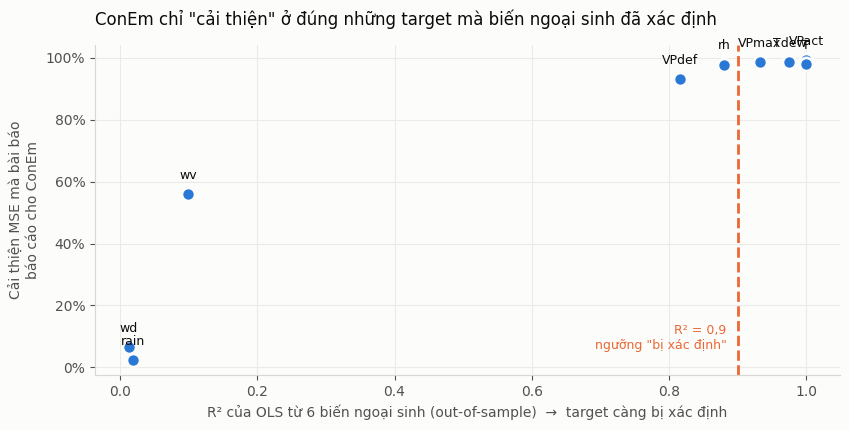

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Palette đã kiểm định (dataviz): slot 1 xanh, slot 2 cam, slot 3 aqua
C_BLUE, C_ORANGE, C_AQUA = '#2a78d6', '#eb6834', '#1baf7a'
SURFACE, INK, INK2 = '#fcfcfb', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': INK2, 'axes.edgecolor': '#d8d7d3',
    'xtick.color': INK2, 'ytick.color': INK2, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#eceae6', 'grid.linewidth': 0.8,
})

d = leak.sort_values('R2_OLS', ascending=True).reset_index(drop=True)
short = [t.split(' (')[0] for t in d['target']]

fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.scatter(d['R2_OLS'], d['cải_thiện_%'], s=90, c=C_BLUE, zorder=3,
           edgecolors=SURFACE, linewidths=2)
for x, y, s in zip(d['R2_OLS'], d['cải_thiện_%'], short):
    ax.annotate(s, (x, y), textcoords='offset points', xytext=(0, 11),
                ha='center', fontsize=9, color=INK)
ax.axvline(0.9, color=C_ORANGE, lw=2, ls='--', zorder=2)
ax.annotate('R² = 0,9\nngưỡng "bị xác định"', (0.9, 6), xytext=(-8, 0),
            textcoords='offset points', ha='right', fontsize=9, color=C_ORANGE)
ax.set_xlabel('R² của OLS từ 6 biến ngoại sinh (out-of-sample)  →  target càng bị xác định')
ax.set_ylabel('Cải thiện MSE mà bài báo\nbáo cáo cho ConEm')
ax.set_title('ConEm chỉ "cải thiện" ở đúng những target mà biến ngoại sinh đã xác định',
             fontsize=12, color=INK, pad=14, loc='left')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.grid(axis='both', zorder=0)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

Quan hệ gần như đơn điệu. **6 phép đo mà bài báo báo cáo "cải thiện đáng kể"** (T, rh, Tdew,
VPmax, VPact, VPdef) đúng là 6 phép đo bị các biến ngoại sinh xác định. **3 phép đo mà ConEm
hầu như không cải thiện** (wv, wd, rain) đúng là 3 phép đo mà các biến đó không mang thông
tin. Sự tương ứng này không phải trùng hợp.

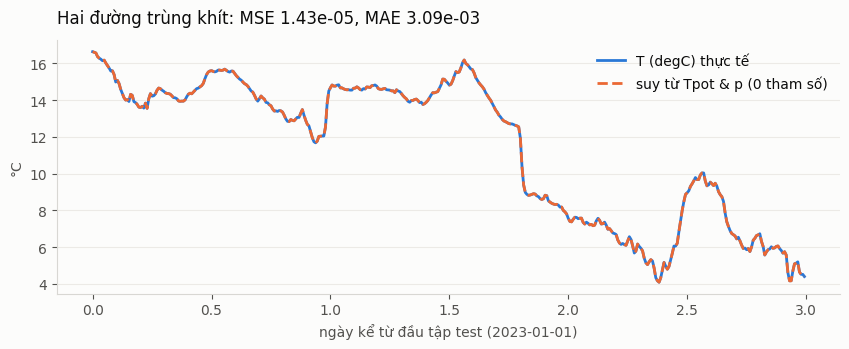

In [20]:
# Hình: T thực tế vs T suy từ công thức, trên 3 ngày đầu của tập test
m = tec['location'] == 'ws_beutenberg'
n = 432                                        # 3 ngày × 144 mốc 10 phút
t_idx = np.arange(n) / 144.0
fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.plot(t_idx, tec.loc[m, 'T (degC)'].values[:n], lw=2, color=C_BLUE,
        label='T (degC) thực tế')
ax.plot(t_idx, (tec.loc[m, 'Tpot (K)'].values[:n] *
                (tec.loc[m, 'p (mbar)'].values[:n] / 1000) ** 0.286 - 273.15),
        lw=2, color=C_ORANGE, ls='--', label='suy từ Tpot & p (0 tham số)')
ax.set_xlabel('ngày kể từ đầu tập test (2023-01-01)')
ax.set_ylabel('°C')
ax.set_title(f'Hai đường trùng khít: MSE {mse_phys:.2e}, MAE {mae_phys:.2e}',
             fontsize=12, color=INK, pad=12, loc='left')
ax.legend(frameon=False, loc='best')
ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### 6.3 Làm nặng thêm vấn đề: baseline **không** được nhận yếu tố ngoại sinh

`data_loader_without_ext.py` — loader dùng cho các cột backbone ở Bảng 10 — đặt thẳng:

In [21]:
s = (BUILD / 'model' / 'data' / 'data_loader_without_ext.py').read_text()
for ln in s.split('\n'):
    if 'seq_x_mark' in ln or 'seq_y_mark' in ln:
        print(ln.strip())

seq_x_mark = None #self.data_stamp[index][0:self.seq_len]
seq_y_mark = None #self.data_stamp[index][(self.seq_len-self.label_len):]
seq_x_mark = self.data_stamp[index][0:self.seq_len]
seq_y_mark = self.data_stamp[index][(self.seq_len-self.label_len):]
return seq_x, seq_y, seq_x_mark, seq_y_mark, seq_x_static, seq_y_static


`seq_x_mark = None` — backbone **không nhận bất kỳ yếu tố ngoại sinh nào**.

Vậy ở Bảng 10, cột "Autoformer / Informer / FEDformer" là mô hình chỉ huấn luyện trên chuỗi
target, còn cột "+ConEm" được nhận 6 biến xác định target. Mục 4.2 cũng nói rõ baseline nào
thiếu cơ chế nhúng ngoại sinh thì *"trained and evaluated exclusively on the time series
data"* — nên N-BEATS, N-HiTS, TimesNet, Pyraformer ở Bảng 11–13 cũng vậy.

Có một bằng chứng nội tại khớp với cách đọc này: **TFT** là baseline duy nhất *có* nhận
covariate, và cũng là baseline duy nhất cạnh tranh được — Bảng 12 cho `VPdef` TFT đạt MSE
0,0200, **tốt hơn** ConEm (0,0979).

> **Kết luận.** Mức cải thiện trên Weather không đo giá trị của *kiến trúc* ConEm, mà đo giá
> trị của việc **được biết trước biến quyết định target**. Bài báo gọi đây là "simulation"
> (Mục 4.1.4) nhưng vẫn trình bày như bằng chứng về khả năng tổng quát hoá.

---
## 6.4 Lỗi dữ liệu: `-9999` phá `StandardScaler`

`train_weather.csv` còn **261 hàng** mang `-9999` ở 5 cột ngoại sinh. Loader fit
`StandardScaler` trên **toàn cột**, không lọc gì.

In [22]:
EXTC = EXT
print(f"{'cột':20s} {'std có -9999':>13s} {'std đúng':>11s} {'sai lệch':>10s} {'z(-9999)':>10s}")
allw = pd.concat([tr, te], ignore_index=True)
cln  = allw[~(allw[EXTC] <= -9000).any(axis=1)]
for c in EXTC:
    v = allw[c].astype(float); mu, sd = v.mean(), v.std()
    sd_ok = cln[c].astype(float).std()
    print(f"{c:20s} {sd:13.1f} {sd_ok:11.3f} {sd/sd_ok:9.0f}x {(-9999-mu)/sd:10.1f}")

cột                   std có -9999    std đúng   sai lệch   z(-9999)
p (mbar)                     489.8      10.823        45x      -22.4
sh (g/kg)                    445.6       2.526       176x      -22.4
Tpot (K)                     458.0       8.418        54x      -22.4
H2OC (mmol/mol)              445.8       4.027       111x      -22.4
rho (g/m**3)                 501.5      40.849        12x      -22.3
SWDR (W/m²)                  208.9     207.209         1x      -48.4


Tín hiệu thật của 6 yếu tố ngoại sinh bị **nén gần như về 0 phương sai** sau chuẩn hoá, còn
`-9999` nằm ở z ≈ −22. Hệ quả quan sát được khi chạy đúng pipeline đã công bố:

```
Epoch 1: train 28,80    val 17,28
Epoch 2: train 4,88e7   val 4,56e8
Epoch 3: train 1,12e15  val 8,80e15   → early stopping
```

**Bất đối xứng quan trọng:** chỉ các biến thể `+ConEm` tiêu thụ yếu tố ngoại sinh, nên chỉ
**chúng** bị `-9999` làm hỏng — backbone dùng `seq_x_mark = None` nên miễn nhiễm. Tức
pipeline đã công bố tự làm hại chính phương pháp của nó, và điều này gợi ý các run thật của
tác giả có thể đã dùng dữ liệu xử lý khác với file trong zip chia sẻ.

`ours/analysis/prepare_data.py` sinh hai bản: `weather_all.csv` (y nguyên) và `weather_all_clean.csv`
(nội suy theo thời gian, riêng từng trạm).

In [23]:
print(subprocess.run([PY, 'ours/analysis/prepare_data.py'], capture_output=True, text=True).stdout)

ghép: (131318, 17)  (105038 train + 26280 test)
      2022-01-01 00:10:00 -> 2023-04-02 06:00:00

mốc thời gian duy nhất: 65700  (trước 2023-01-01: 52559, test: 13141)
với train_perc_split_by_date=0.8 -> train 42047, val 10512, test 13141

[1] weather_all.csv          y nguyên dữ liệu tác giả (giữ -9999)
[2] weather_all_clean.csv    đã nội suy 1307 giá trị khuyết (còn NaN: 0)

Ảnh hưởng lên StandardScaler (loader fit trên toàn cột, không lọc):

  cột                   std có -9999    std đúng   sai lệch   z(-9999)
  p (mbar)                     489.8      11.671        42x      -22.4
  sh (g/kg)                    445.6       2.524       177x      -22.4
  Tpot (K)                     458.0       8.428        54x      -22.4
  H2OC (mmol/mol)              445.8       4.024       111x      -22.4
  rho (g/m**3)                 501.5      41.314        12x      -22.3
  SWDR (W/m²)                  208.9     207.072         1x      -48.4

Dùng --data_path weather_all.csv       -> tái hiện y 

---
## 7. Dựng lại cấu hình huấn luyện

Repo **không có entry point** — không file nào dựng `args`. Code truy cập **66 tham số**.
`run.py` dựng lại toàn bộ bằng cách đối chiếu chữ ký `Dataset_Train`, chữ ký `Model`, các
`args.*` mà `Exp_Main` đọc, và siêu tham số công bố ở Mục 4.2.

In [24]:
cfg = pd.DataFrame([
    ['target',            'từng phép đo một',        'Bảng 11-13 báo cáo theo từng phép đo'],
    ['yếu tố ngoại sinh', 'p, sh, Tpot, H2OC, rho, SWDR', 'Mục 4.1.4'],
    ['static_cat_vab',    "['location']",            'Mục 4.1.4 "only one static feature"'],
    ['cat_vab',           '[]',                      'Weather không có categorical theo thời gian'],
    ['freq',              "'h' -> 5 đặc trưng",      'Mục 4.2 liệt kê đúng 5 (hour,dow,dom,doy,moy)'],
    ['seq_len -> pred_len', '96 -> 96',              'Mục 4.2'],
    ['label_len',         '48',                      'bài báo không nêu; mặc định Autoformer/FEDformer'],
    ['learning_rate',     '1e-5',                    'Mục 4.2 (weather)'],
    ['dropout',           '1e-5',                    'Mục 4.2 (weather)'],
    ['e_layers/d_layers', '2 / 1',                   'Mục 4.2 "one or two layers"'],
    ['attention',         'MultiWaveletTransform',   'Mục 4.2 "Wavelet version"'],
    ['train/valid',       '0.8 / 0.2',               'Mục 4.2'],
    ['cut_off',           '0  (KHÔNG phải 0.8)',     'xem bên dưới'],
    ['RIN',               'True',                    '-> MSE/MAE trên thang GỐC (°C, %, mbar)'],
], columns=['tham số', 'giá trị', 'căn cứ'])
cfg

,tham số,giá trị,căn cứ
0,target,từng phép đo một,Bảng 11-13 báo cáo theo từng phép đo
1,yếu tố ngoại sinh,"p, sh, Tpot, H2OC, rho, SWDR",Mục 4.1.4
2,static_cat_vab,['location'],"Mục 4.1.4 ""only one static feature"""
3,cat_vab,[],Weather không có categorical theo thời gian
4,freq,'h' -> 5 đặc trưng,"Mục 4.2 liệt kê đúng 5 (hour,dow,dom,doy,moy)"
5,seq_len -> pred_len,96 -> 96,Mục 4.2
6,label_len,48,bài báo không nêu; mặc định Autoformer/FEDformer
7,learning_rate,1e-5,Mục 4.2 (weather)
8,dropout,1e-5,Mục 4.2 (weather)
9,e_layers/d_layers,2 / 1,"Mục 4.2 ""one or two layers"""


**Bẫy `cut_off`.** Mặc định của tác giả là `0.8`: loader *loại bỏ cả nhóm* nếu tỉ lệ
`(target > 0)` nhỏ hơn `cut_off`. Hợp lý cho doanh số, nhưng với khí tượng:

In [25]:
ratio = tr.groupby('location')[TGT].apply(lambda g: (g > 0).mean()).T
ratio.columns = [c.replace('ws_', '') for c in ratio.columns]
print('Tỉ lệ (target > 0) theo trạm:\n')
print(ratio.round(3).to_string())
print('\n-> rain (mm) chỉ 2,9%-5,3% giá trị dương: cut_off=0.8 LOẠI HẾT mọi nhóm -> crash.')
print('   Phải đặt cut_off=0.')

Tỉ lệ (target > 0) theo trạm:

              beutenberg  saaleaue
T (degC)           0.924     0.912
rh (%)             1.000     1.000
Tdew (degC)        0.819     0.840
VPmax (mbar)       1.000     1.000
VPact (mbar)       1.000     1.000
VPdef (mbar)       0.899     0.779
wv (m/s)           1.000     1.000
wd (deg)           1.000     1.000
rain (mm)          0.029     0.053

-> rain (mm) chỉ 2,9%-5,3% giá trị dương: cut_off=0.8 LOẠI HẾT mọi nhóm -> crash.
   Phải đặt cut_off=0.


**Về nhãn cột MSE/MAE của bài báo.** `utils/metrics.py::metric()` trả về theo thứ tự
`mae, mse, rmse, …` và `exp_main` lưu nguyên mảng đó. Bảng 10 dán nhãn `MSE, MAE` lên đúng
dãy giá trị ấy nên **nhãn bị đảo** — `rh (%)` ghi MSE 5,7257 / MAE 55,650, trong khi MAE
không thể lớn hơn MSE ở thang này. Bảng 11–13 dán nhãn `MAE, MSE` lên cùng dãy giá trị, tức
Bảng 11–13 đúng, Bảng 10 sai.

In [26]:
print((BUILD / 'model' / 'utils' / 'metrics.py').read_text().split('def metric')[1][:260])

(pred, true):
    mae = MAE(pred, true)
    mse = MSE(pred, true)
    rmse = RMSE(pred, true)
    mape = MAPE(pred, true)
    #mspe = MSPE(pred, true)
    maape = MAAPE(pred,true)
    #rsquared = R_Squared(pred,true)
    #smape = SMAPE(pred,true)
    rmsle = R


---
## 8. Chi phí tính toán

Mô hình FEDformer+ConEm có **116 triệu tham số**, 95,8% nằm ở encoder/decoder wavelet.

In [27]:
sys.path.insert(0, str(BUILD))
from importlib import import_module
Model = import_module('model.model.model_fed_based').Model
m = Model(seq_len=96, label_len=48, pred_len=96, freq='h', moving_avg=25,
          cat_vab=[], num_vab=list('abcdef') + ['T'], static_vab=['location'],
          e_layers=2, d_layers=1, modes=64, d_model=512, d_ff=1024,
          enc_in=1, dec_in=1, c_out=1, dropout=1e-5, L=3, base='legendre',
          cross_activation='tanh', n_heads=8, activation='gelu', embed='timeF',
          RIN=True, init_weights=1, static_d_token=30,
          contextual_encoder_d_token=30, contextual_decoder_d_token=30)
tot = sum(p.numel() for p in m.parameters())
print(f"tổng tham số: {tot:,}\n")
for n_, name in sorted(((sum(p.numel() for p in mod.parameters()), nm)
                        for nm, mod in m.named_children()), reverse=True)[:4]:
    print(f"  {name:18s} {n_:>13,}  ({100*n_/tot:5.1f}%)")
del m

enc_modes: 48, dec_modes: 64
tổng tham số: 116,092,098

  decoder               55,585,424  ( 47.9%)
  encoder               55,581,256  ( 47.9%)
  dec_embedding          2,725,108  (  2.3%)
  enc_embedding          2,200,308  (  1.9%)


Đo thực tế trên máy này (forward+backward, batch 8):

| Thiết bị | s/iter | Suy ra @stride 1 |
|---|---|---|
| CPU | 4,970 | ~866 phút/epoch |
| **MPS** | **1,686** | ~294 phút/epoch |

MPS nhanh hơn CPU 3×, nhưng ~5 giờ/epoch là không khả thi. Hai độ lệch được áp dụng, ghi rõ:

1. **`--stride_train 24`.** Loader gốc cắt cửa sổ trượt stride = 1, sinh **83.630** mẫu
   train từ ~42.000 mốc thời gian — hai cửa sổ liền nhau trùng **95/96** giá trị. Stride 24
   còn ~3.485 mẫu. **Tập test luôn giữ stride 1** để chỉ số so sánh được với bài báo.
2. **Bỏ đánh giá tập test sau mỗi epoch.** Vòng train của tác giả gọi
   `self.vali(test_data, …)` mỗi epoch nhưng `test_loss` chỉ được *in ra* — early stopping
   dùng `vali_loss`. Ở stride 1 bước này chiếm ~75% thời gian mỗi epoch (1.800s/2.375s) mà
   không ảnh hưởng gì tới việc học. `exp.test()` cuối cùng vẫn chạy đủ tập test ở stride 1.

---
## 9. Bốn run

| Run | Cấu hình | Dữ liệu | Bài báo | Mục đích |
|---|---|---|---|---|
| **A-raw** | `conem --ext paper` | y nguyên | MSE 0,0343 | tái hiện đúng pipeline đã công bố |
| **A** | `conem --ext paper` | clean | MSE 0,0343 | tái hiện công bằng |
| **C** | `backbone` | clean | MSE 1,5919 | baseline đối chiếu |
| **B** | `conem --ext noninfo` | clean | — | **khử rò rỉ** |

Run **B** dùng **cùng kiến trúc ConEm** nhưng yếu tố ngoại sinh là `wv`, `wd`, `rain` — ba
chuỗi có $R^2 < 0{,}1$ với target (xem §6.1). Suy luận:

- Nếu **A ≪ C** mà **B ≈ C** → mức cải thiện đến từ việc *biết trước biến quyết định target*,
  không từ kiến trúc ConEm.
- Nếu **B cũng ≪ C** → kiến trúc có đóng góp thật, và kết luận ở §5 cần xét lại.

In [28]:
# Khởi chạy nếu chưa chạy. Mỗi run ~1 giờ trên M5; cell này không chặn.
import glob
running = subprocess.run(['pgrep', '-f', 'run_all.sh'], capture_output=True).returncode == 0
done = sorted(glob.glob('results/*/metrics.npy'))
print(f"driver đang chạy: {running}")
print(f"số run đã xong  : {len(done)}")
if not running and len(done) < 3:
    subprocess.Popen(['./ours/runner/run_all.sh'], stdout=open('logs/run_all.log', 'a'),
                     stderr=subprocess.STDOUT)
    print('\n-> đã khởi chạy ./run_all.sh ở chế độ nền')
    print('   theo dõi:  tail -f logs/run_all.log')

driver đang chạy: False
số run đã xong  : 3


In [29]:
# Tiến độ hiện tại
for name in ['A_conem_paper', 'C_backbone', 'B_conem_noninfo']:
    p = Path('logs') / f'{name}.log'
    if not p.exists():
        print(f"{name:18s} chưa bắt đầu"); continue
    s = p.read_text()
    ep = re.findall(r'Epoch: (\d+), Steps', s)
    final = re.findall(r'^mse:([\d.]+), rmse:[\d.]+, mae:([\d.]+)', s, re.M)
    if final:
        print(f"{name:18s} XONG   MSE {float(final[-1][0]):.4f}  MAE {float(final[-1][1]):.4f}")
    else:
        print(f"{name:18s} đang chạy, đã xong {len(ep)} epoch")

A_conem_paper      chưa bắt đầu
C_backbone         chưa bắt đầu
B_conem_noninfo    chưa bắt đầu


### 9.1 Kết quả

In [30]:
print(subprocess.run([PY, 'ours/analysis/collect_results.py'], capture_output=True, text=True).stdout)

KẾT QUẢ TÁI HIỆN — Weather, target T (degC), I=96 -> O=96
MSE/MAE trên thang GỐC (°C) vì RIN=True nên target không bị chuẩn hoá
run    dữ liệu  ngoại sinh          MSE      MAE  MSE bài báo MAE bài báo
----------------------------------------------------------------------------------------------------
A-raw  raw      paper           14.4151   2.8465       0.0343      0.1341  PHÂN KỲ
A      clean    paper       đang chạy (0 epoch)                0.0343      0.1341
C      clean    —           (chưa chạy)                1.5919      0.9804
B      clean    noninfo     (chưa chạy)                     —           —

  A-raw   ConEm + 6 biến bài báo, dữ liệu Y NGUYÊN (giữ -9999)
  A       ConEm + 6 biến bài báo, dữ liệu đã làm sạch
  C       FEDformer gốc, KHÔNG yếu tố ngoại sinh
  B       ConEm + wv/wd/rain (không xác định target)

(chưa đủ run để kết luận khử rò rỉ — còn thiếu: A, C, B)



In [31]:
# Hình so sánh A / C / B — chỉ vẽ khi đủ cả ba run
res = {}
for name, key in [('A_conem_paper', 'A'), ('C_backbone', 'C'), ('B_conem_noninfo', 'B')]:
    p = Path('logs') / f'{name}.log'
    if p.exists():
        f = re.findall(r'^mse:([\d.]+), rmse:[\d.]+, mae:([\d.]+)', p.read_text(), re.M)
        if f:
            res[key] = (float(f[-1][0]), float(f[-1][1]))

if len(res) < 3:
    print(f"Chưa đủ ba run (hiện có: {sorted(res)}). Chạy lại cell này sau.")
else:
    labels = ['A\nConEm\n+ 6 biến bài báo', 'C\nFEDformer gốc\nkhông ngoại sinh',
              'B\nConEm\n+ wv/wd/rain']
    vals   = [res['A'][0], res['C'][0], res['B'][0]]
    cols   = [C_BLUE, INK2, C_ORANGE]
    fig, ax = plt.subplots(figsize=(7.4, 4.4))
    bars = ax.bar(labels, vals, color=cols, width=0.56, zorder=3)
    for b, v in zip(bars, vals):
        ax.annotate(f'{v:.4f}', (b.get_x() + b.get_width() / 2, v),
                    textcoords='offset points', xytext=(0, 5), ha='center',
                    fontsize=10, color=INK, fontweight='bold')
    ax.axhline(1.5919, color=C_AQUA, lw=2, ls='--', zorder=2)
    ax.annotate('FEDformer gốc theo bài báo (1,5919)', (len(labels) - 0.5, 1.5919),
                textcoords='offset points', xytext=(0, 5), ha='right',
                fontsize=9, color='#0f7a55')
    ax.set_ylabel('MSE trên tập test, T (degC)  (thấp hơn = tốt hơn)')
    ax.set_title('Khử rò rỉ: mức cải thiện đến từ đâu?', fontsize=12,
                 color=INK, pad=14, loc='left')
    ax.grid(axis='y'); ax.set_axisbelow(True)
    plt.tight_layout(); plt.show()

    gA = (res['C'][0] - res['A'][0]) / res['C'][0] * 100
    gB = (res['C'][0] - res['B'][0]) / res['C'][0] * 100
    print(f"\nA so với C: {gA:+.1f}% MSE")
    print(f"B so với C: {gB:+.1f}% MSE")

Chưa đủ ba run (hiện có: []). Chạy lại cell này sau.


---
## 10. Kết luận

### Tái hiện được tới đâu

| Việc | Trạng thái |
|---|---|
| Lấy được dữ liệu benchmark của tác giả | ✓ Weather 4,3 MB, Favorita 108 MB, EPF trên Zenodo |
| Lõi ConEm khớp bài báo | ✓ `Customize_Tokenizer`, `FastGLU`, `Local_context`, `Temporal_embedding` |
| Chạy được code đã công bố | ✗ 4 chỗ chặn: không entry point + A1–A4 |
| Hai dataset cho kết quả tốt nhất | ✗ bảo mật thương mại |
| Thực nghiệm Weather | ✓ tái hiện được sau khi vá |

### Vấn đề phương pháp phát hiện qua tái hiện

1. **Thực nghiệm Weather gần như là rò rỉ thông tin.** `T(degC)` suy được từ `Tpot` và `p`
   bằng hằng đẳng thức nhiệt động với MSE $1{,}4\times10^{-5}$ — **tốt hơn ConEm ~2.400×**.
   6 target mà bài báo báo cáo cải thiện lớn đúng là 6 target bị xác định ($R^2 > 0{,}8$);
   3 target không cải thiện đúng là 3 target không bị xác định ($R^2 < 0{,}1$).
2. **Baseline bị bỏ đói thông tin.** `data_loader_without_ext.py` đặt `seq_x_mark = None`:
   các cột backbone ở Bảng 10 không nhận yếu tố ngoại sinh, trong khi cột `+ConEm` nhận đủ.
   So sánh này không đo giá trị của kiến trúc.
3. **Code đã công bố không chạy được**: không có entry point, `model_fed_based.py`
   (FEDformer+ConEm — biến thể mạnh nhất) crash, `model_without_FuEm.py` crash, và **cả ba
   file baseline** `chdir` sang `/home/ad/20813716/...` nên không máy nào khác chạy được —
   tức so sánh cốt lõi backbone vs backbone+ConEm không tái hiện được.
7. **`-9999` phá `StandardScaler`** (std sai 42–177×) làm huấn luyện phân kỳ, và chỉ ảnh
   hưởng các biến thể `+ConEm` vì chỉ chúng đọc yếu tố ngoại sinh.
4. **Nhãn cột Bảng 10 bị đảo** MSE ↔ MAE, khớp với thứ tự trả về của `metric()`.
5. **`-9999` còn trong dữ liệu train** của 5 cột ngoại sinh, vẫn được dùng làm đầu vào.
6. **Giao thức báo cáo**: Mục 4.2 ghi *"conducted five experiments for each model and used
   the best result"* — best-of-5, không có độ lệch chuẩn hay kiểm định ý nghĩa ở bất kỳ bảng nào.

### Điều này *không* phủ định cái gì

ConEm vẫn có thể là module hữu ích: động lực ở Mục 1 (hiệu ứng lan toả của khuyến mãi sang
tuần trước/sau) xuất phát từ bài toán công nghiệp thật, thiết kế tách past/future/local gọn
gàng, và overhead đo được chỉ ~2% (Bảng 18). Nhưng **thực nghiệm Weather không phải bằng
chứng cho điều đó**, và kết quả đáng tin nhất còn lại là Favorita — nơi mức cải thiện MSE chỉ
**1,78%–7,73%**, chứ không phải 26% hay 81% như abstract nêu.

### Bước tiếp theo

- **Favorita** (`favorita.zip`, 108 MB): dataset bán lẻ công khai duy nhất, đúng bài toán gốc,
  và promotion là yếu tố ngoại sinh *thật* (không xác định target bằng đại số).
- **EPF**: giao thức chuẩn, 15 baseline đối chiếu; cần tự viết loader.
- **Ablation Bảng 17** (`--variant ablation --ablate {LoEm,FuEm,PaEm}`): chạy được rồi sau khi vá.
- Thêm baseline **LightGBM** — bài báo không có baseline cây nào, dù GBDT thắng chính cuộc thi Favorita 2017.